In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

claims = pd.read_parquet(Path("data") / "claims_prepared.parquet")
portfolio_frequency = claims["ClaimNb"].sum() / claims["Exposure"].sum()
print(claims.shape, round(portfolio_frequency, 6))

(678013, 12) 0.100703


In [2]:
def weighted_frequency(frame, group):
    table = frame.groupby(group, observed=False).agg(
        exposure=("Exposure", "sum"), claims=("ClaimNb", "sum")
    )
    table["frequency"] = table["claims"] / table["exposure"]
    return table


def frequency_with_volume(table, ax, title):
    positions = np.arange(len(table))
    ax.bar(positions, table["exposure"], color="lightgrey")
    ax.set_ylabel("exposure-years")
    ax.set_xticks(positions)
    ax.set_xticklabels([str(index) for index in table.index], rotation=45, ha="right")
    ax.set_title(title)
    frequency_axis = ax.twinx()
    frequency_axis.plot(positions, table["frequency"], color="crimson", marker="o")
    frequency_axis.axhline(portfolio_frequency, color="black", linestyle="--", linewidth=0.8)
    frequency_axis.set_ylabel("frequency")
    frequency_axis.set_ylim(bottom=0)

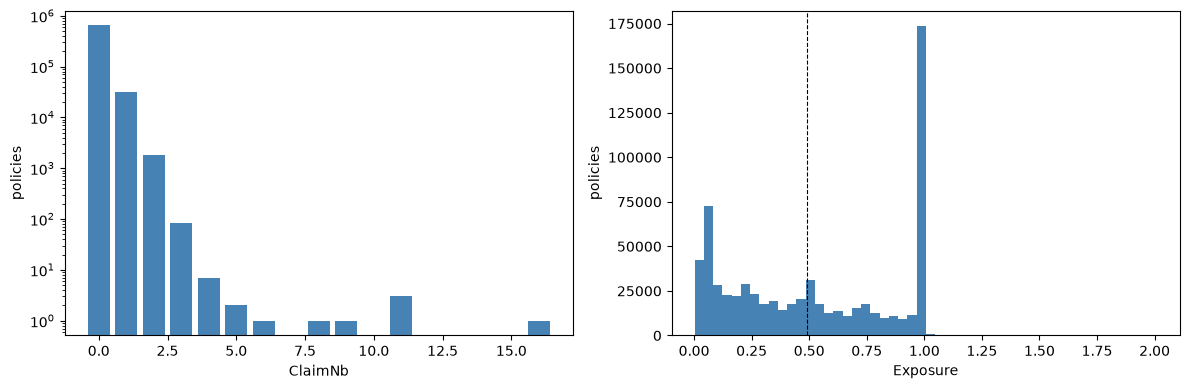

In [3]:
claim_counts = claims["ClaimNb"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(claim_counts.index, claim_counts.values, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_xlabel("ClaimNb")
axes[0].set_ylabel("policies")
axes[1].hist(claims["Exposure"], bins=50, color="steelblue")
axes[1].axvline(claims["Exposure"].median(), color="black", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Exposure")
axes[1].set_ylabel("policies")
fig.tight_layout()
plt.show()

                     exposure  claims  frequency
BonusMalus                                      
(0.0, 50.0]     225233.130903   18056   0.080166
(50.0, 60.0]     47985.497013    4553   0.094883
(60.0, 80.0]     53065.346794    7057   0.132987
(80.0, 100.0]    28644.151750    5094   0.177837
(100.0, 120.0]    2573.003003     873   0.339292
(120.0, 150.0]     903.187803     415   0.459484
(150.0, inf]        95.128197      54   0.567655


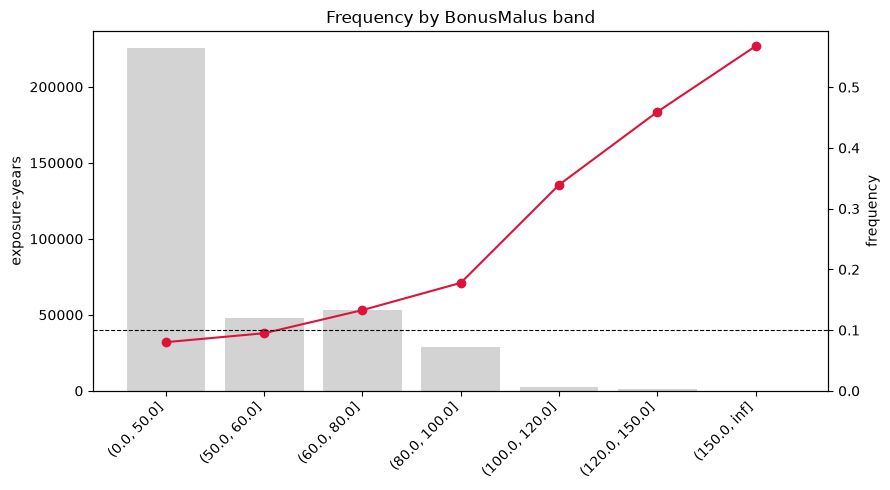

In [4]:
bonus_malus_band = pd.cut(claims["BonusMalus"], bins=[0, 50, 60, 80, 100, 120, 150, np.inf])
assert bonus_malus_band.isna().sum() == 0
bonus_malus_frequency = weighted_frequency(claims, bonus_malus_band)
print(bonus_malus_frequency)
fig, ax = plt.subplots(figsize=(9, 5))
frequency_with_volume(bonus_malus_frequency, ax, "Frequency by BonusMalus band")
fig.tight_layout()
plt.show()

                  exposure  claims  frequency
DrivAge                                      
(17.0, 21.0]   4404.683976     996   0.226123
(21.0, 25.0]  11823.219287    1845   0.156049
(25.0, 30.0]  29180.233819    3093   0.105996
(30.0, 40.0]  83937.299011    7522   0.089615
(40.0, 50.0]  88138.310203    9165   0.103984
(50.0, 60.0]  75727.636010    7292   0.096292
(60.0, 70.0]  38332.688531    3566   0.093028
(70.0, inf]   26955.374625    2623   0.097309


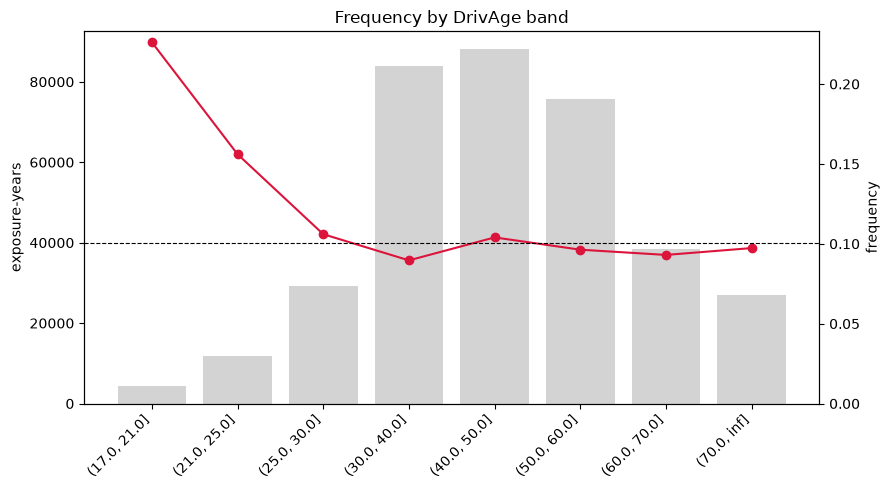

In [5]:
driv_age_band = pd.cut(claims["DrivAge"], bins=[17, 21, 25, 30, 40, 50, 60, 70, np.inf])
assert driv_age_band.isna().sum() == 0
driv_age_frequency = weighted_frequency(claims, driv_age_band)
print(driv_age_frequency)
fig, ax = plt.subplots(figsize=(9, 5))
frequency_with_volume(driv_age_frequency, ax, "Frequency by DrivAge band")
fig.tight_layout()
plt.show()

           exposure  claims  frequency
Area                                  
A      61969.377712    5063   0.081702
B      43012.323931    3800   0.088347
C     104449.003785    9875   0.094544
D      77120.191692    8428   0.109284
E      63819.314270    7805   0.122298
F       8129.234074    1131   0.139127
                     exposure  claims  frequency
Density                                         
(-0.0102, 1.02]     51.820000       4   0.077190
(1.02, 2.041]     1575.351472     126   0.079982
(2.041, 3.061]   20996.753526    1625   0.077393
(3.061, 4.081]   51437.978429    4337   0.084315
(4.081, 5.102]   63069.462228    5690   0.090218
(5.102, 6.122]   65033.263592    6190   0.095182
(6.122, 7.143]   55118.302308    5974   0.108385
(7.143, 8.163]   55861.541304    6458   0.115607
(8.163, 9.183]   36915.102981    4537   0.122904
(9.183, 10.204]   8439.869623    1161   0.137561


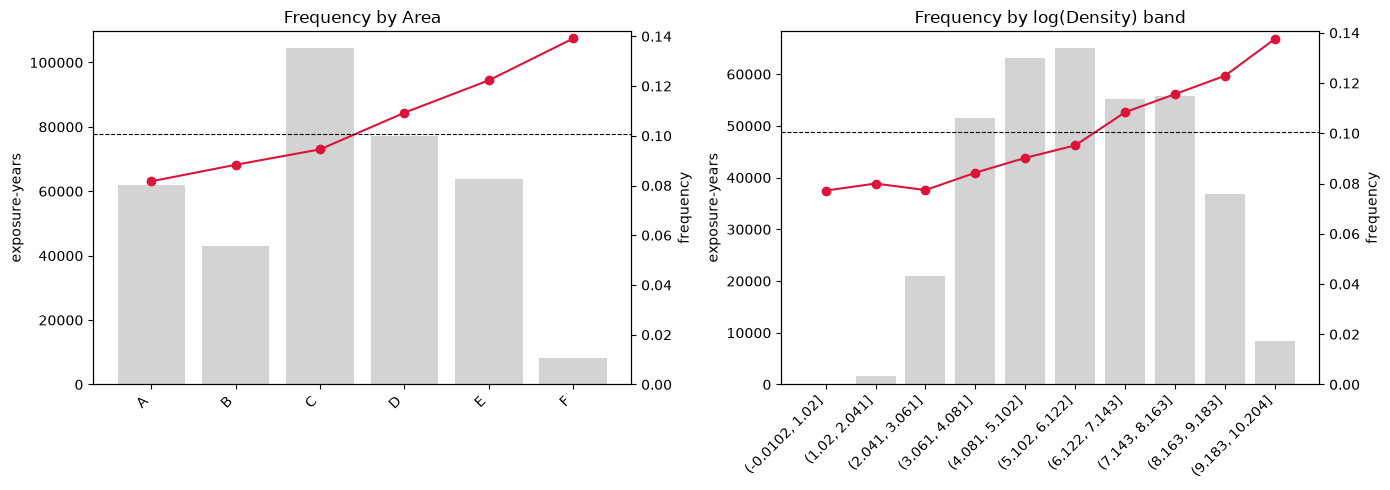

In [6]:
log_density = np.log(claims["Density"])
log_density_band = pd.cut(log_density, bins=10)
assert log_density_band.isna().sum() == 0
area_frequency = weighted_frequency(claims, claims["Area"])
log_density_frequency = weighted_frequency(claims, log_density_band)
print(area_frequency)
print(log_density_frequency)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
frequency_with_volume(area_frequency, axes[0], "Frequency by Area")
frequency_with_volume(log_density_frequency, axes[1], "Frequency by log(Density) band")
fig.tight_layout()
plt.show()

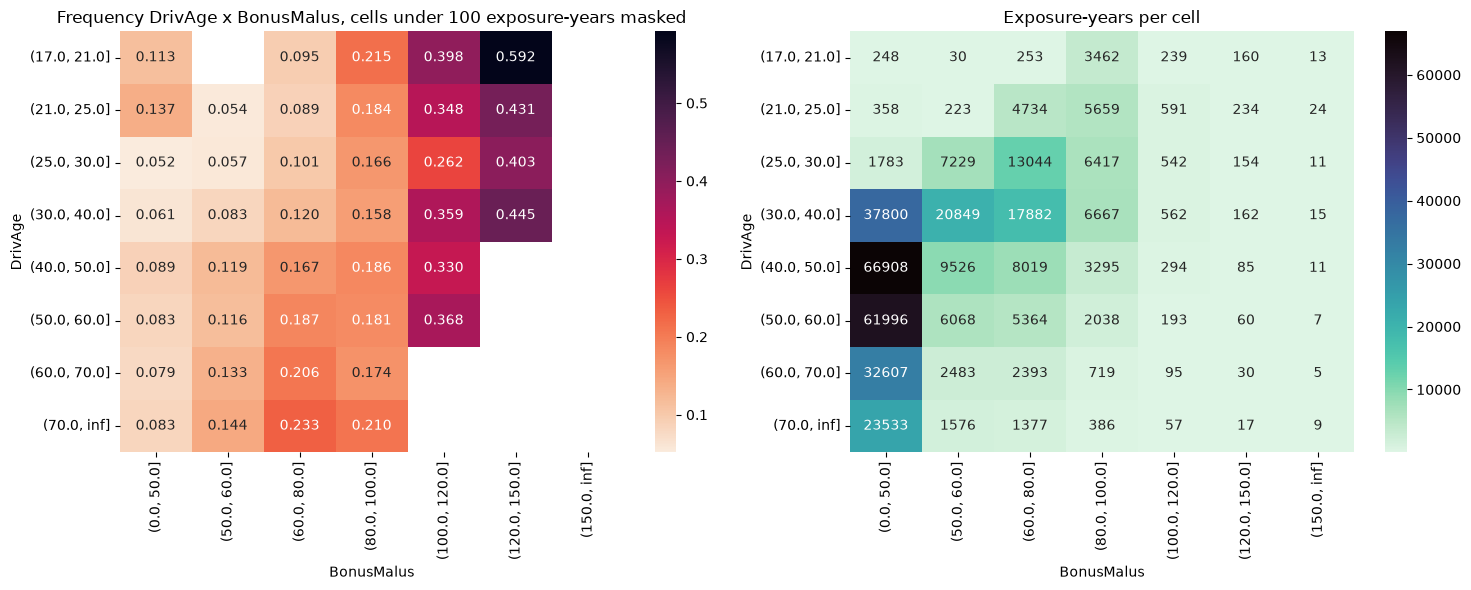

In [7]:
heatmap_driv_age = pd.cut(claims["DrivAge"], bins=[17, 21, 25, 30, 40, 50, 60, 70, np.inf])
heatmap_bonus_malus = pd.cut(claims["BonusMalus"], bins=[0, 50, 60, 80, 100, 120, 150, np.inf])
assert heatmap_driv_age.isna().sum() == 0
assert heatmap_bonus_malus.isna().sum() == 0
interaction = claims.groupby([heatmap_driv_age, heatmap_bonus_malus], observed=False).agg(
    exposure=("Exposure", "sum"), claims=("ClaimNb", "sum")
)
frequency_grid = (interaction["claims"] / interaction["exposure"]).unstack()
exposure_grid = interaction["exposure"].unstack()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(frequency_grid, annot=True, fmt=".3f", cmap="rocket_r", ax=axes[0],
            mask=exposure_grid < 100)
axes[0].set_title("Frequency DrivAge x BonusMalus, cells under 100 exposure-years masked")
sns.heatmap(exposure_grid, annot=True, fmt=".0f", cmap="mako_r", ax=axes[1])
axes[1].set_title("Exposure-years per cell")
fig.tight_layout()
plt.show()

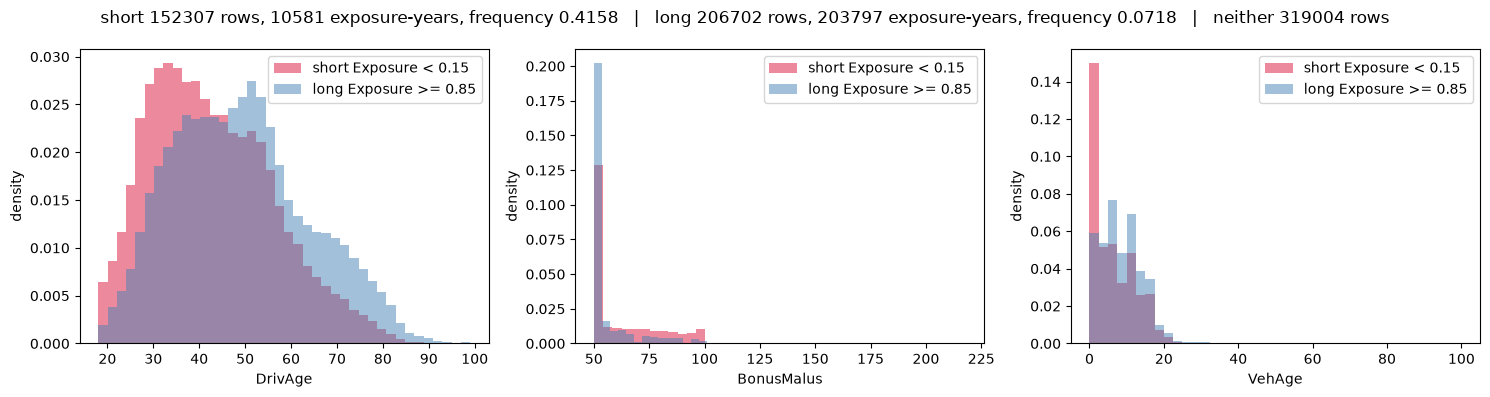

In [8]:
short_policies = claims[claims["Exposure"] < 0.15]
long_policies = claims[claims["Exposure"] >= 0.85]
neither_count = len(claims) - len(short_policies) - len(long_policies)
covariates = ["DrivAge", "BonusMalus", "VehAge"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, covariate in zip(axes, covariates):
    ax.hist(short_policies[covariate], bins=40, density=True, alpha=0.5,
            color="crimson", label="short Exposure < 0.15")
    ax.hist(long_policies[covariate], bins=40, density=True, alpha=0.5,
            color="steelblue", label="long Exposure >= 0.85")
    ax.set_xlabel(covariate)
    ax.set_ylabel("density")
    ax.legend()
fig.suptitle(
    f"short {len(short_policies)} rows, {short_policies['Exposure'].sum():.0f} exposure-years, "
    f"frequency {short_policies['ClaimNb'].sum() / short_policies['Exposure'].sum():.4f}   |   "
    f"long {len(long_policies)} rows, {long_policies['Exposure'].sum():.0f} exposure-years, "
    f"frequency {long_policies['ClaimNb'].sum() / long_policies['Exposure'].sum():.4f}   |   "
    f"neither {neither_count} rows"
)
fig.tight_layout()
plt.show()